In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")


#Data Pre-Processing

In [ ]:
# Checking for missing values
print("Train Missing Values: ", train.isnull().sum().sum())
print("Test Missing Values: ", test.isnull().sum().sum())

# Converting categorical variables into numerical values
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Inflight wifi service',
            'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location',
            'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment',
            'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service',
            'Inflight service', 'Cleanliness']

for col in cat_cols:
    train[col] = train[col].astype('category').cat.codes
    test[col] = test[col].astype('category').cat.codes


Train Missing Values:  310
Test Missing Values:  83


In [ ]:
# Get the summary statistics of the data
print(train.describe())

          Unnamed: 0             id         Gender  Customer Type  \
count  103904.000000  103904.000000  103904.000000  103904.000000   
mean    51951.500000   64924.210502       0.492541       0.182678   
std     29994.645522   37463.812252       0.499947       0.386404   
min         0.000000       1.000000       0.000000       0.000000   
25%     25975.750000   32533.750000       0.000000       0.000000   
50%     51951.500000   64856.500000       0.000000       0.000000   
75%     77927.250000   97368.250000       1.000000       0.000000   
max    103903.000000  129880.000000       1.000000       1.000000   

                 Age  Type of Travel  Flight Distance  Inflight wifi service  \
count  103904.000000   103904.000000    103904.000000          103904.000000   
mean       39.379706        0.310373      1189.448375               2.729683   
std        15.114964        0.462649       997.147281               1.327829   
min         7.000000        0.000000        31.000000     

#Exploratory Data Analysis

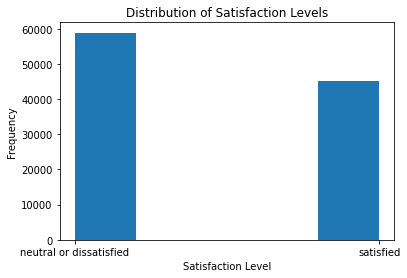

In [ ]:
# Plot the distribution of the satisfaction levels
plt.hist(train['satisfaction'], bins=5)
plt.xlabel("Satisfaction Level")
plt.ylabel("Frequency")
plt.title("Distribution of Satisfaction Levels")
plt.show()

#Are there any significant differences in the satisfaction levels of customers based on their age group?

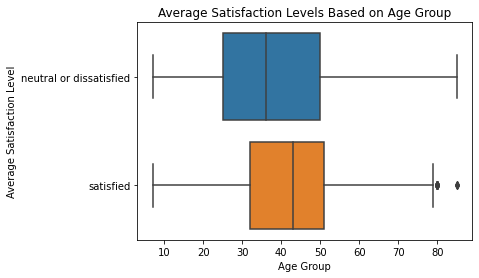

In [ ]:
# Create a box plot to compare the average satisfaction levels of customers based on their age group
sns.boxplot(x='Age', y='satisfaction', data=train)
plt.title("Average Satisfaction Levels Based on Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Satisfaction Level")

plt.show()

#What are the key factors affecting customer satisfaction in the airline industry?

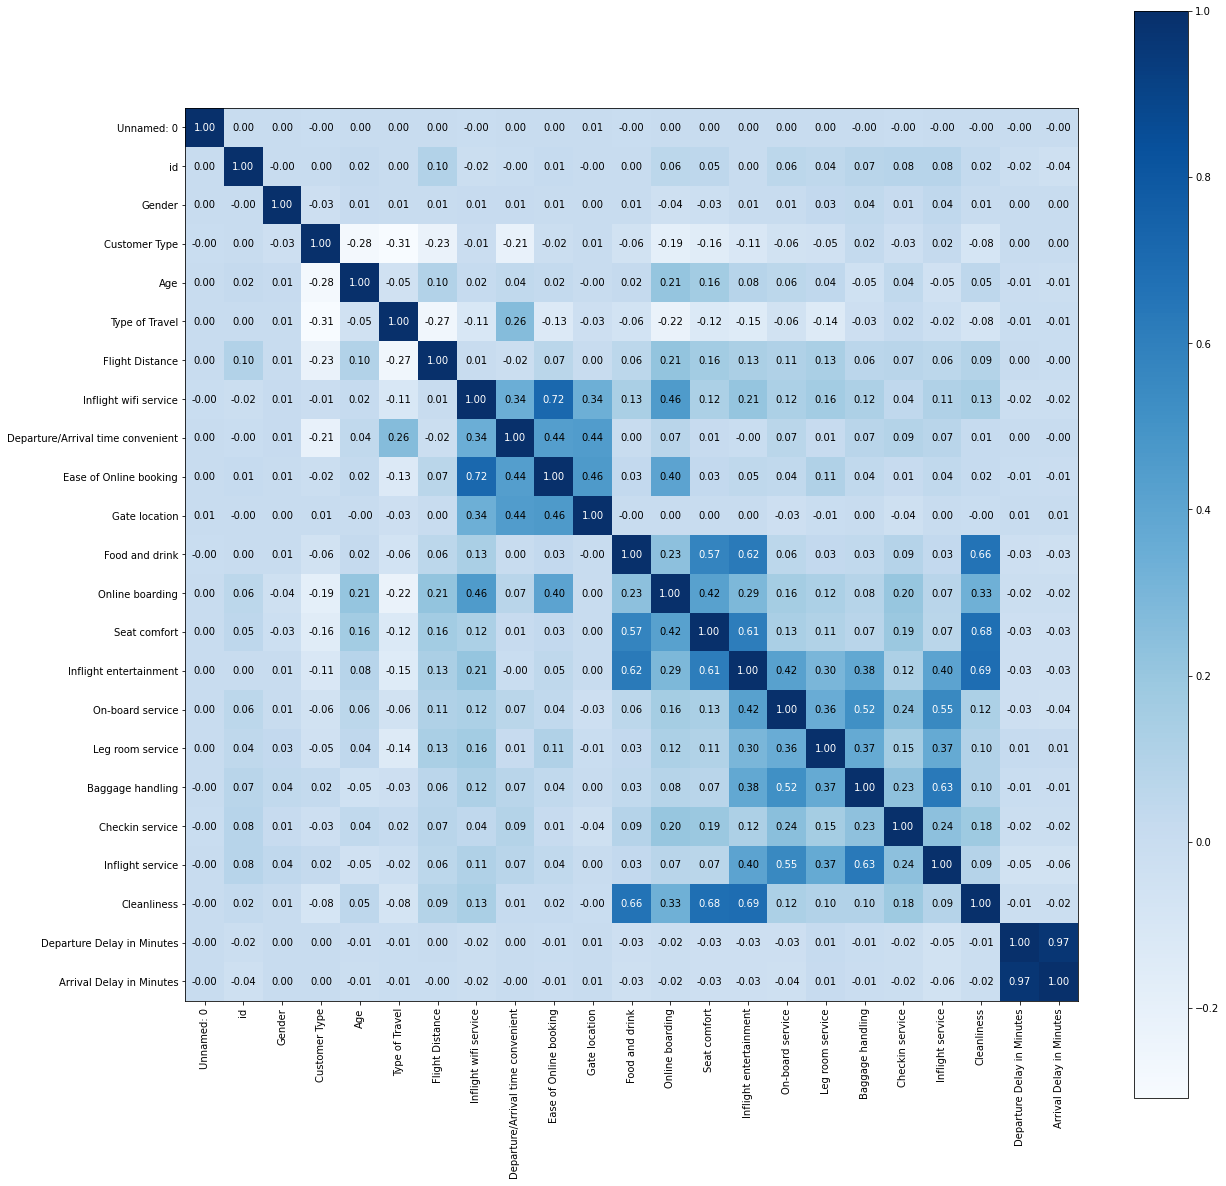

In [ ]:
# Calculate the correlation matrix
corr = train.corr()

# Plot the correlation matrix
plt.figure(figsize=(20,20))
plt.imshow(corr, cmap='Blues')
plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(np.arange(len(corr.columns)), corr.columns)
plt.colorbar()

# Add labels to the squares
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, "{:.2f}".format(corr.iloc[i,j]), ha="center", va="center", color="white" if corr.iloc[i,j] > 0.5 else "black")

# Show the plot
plt.show()